# Variation across subsamples of the same perturbation, before and after `ashr`

Each perturbation is estimated 11 times — once from all its cells (the *main* row) and
once per subsample, at sizes spanning `[50, n_cells)`. This notebook asks what the
shrinkage does to the spread across those 11 estimates.

The question matters because the 11 rows are meant to be the *same estimand at different
precision*. Before shrinkage they should scatter around the main estimate with a spread
that falls as `1/√n`. After shrinkage they may not, because `ashr` pulls low-precision
rows harder — and it fits **one prior per shard across all 11 precision tiers at once**,
so the tiers are not shrunk independently.

Inputs are read-only outputs of `scripts/compute_se_shards.py` and `run_ashr_on_chunk.R`:

```
<computese>/<context>/<shard>/chunk_000000.csv            mean_diff, se   (before)
<computese>/<context>/<shard>/AshrResult_chunk_000000.csv  PosteriorMean   (after)
```

The two align **row for row** — `ashr` echoes its inputs back as `betahat`/`sebetahat`,
which the loader below uses as a checksum before joining anything.

Scope is **one shard** (100 perturbations).


In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

COMPUTESE = Path("/large_storage/ctc/beraslan/ModuleFinder/computese")

CONTEXT = "Stattic"     # a finished context
SHARD = "ad_001"        # one shard = 100 perturbations
N_GENES = 2000          # genes to subsample; None for all 18,154

pd.set_option("display.width", 140)
print("contexts with results:",
      ", ".join(sorted(d.name for d in COMPUTESE.iterdir()
                       if d.is_dir() and d.name != "controls"
                       and any(d.glob("*/AshrResult_chunk_000000.csv")))))

contexts with results: AR-A014418, AZD4573, Bisindolylmaleimide-I, DMSO_round2, DMSO_round2_batch2, Stattic


## 1. Load one shard, before and after

`n_pert` is the number of cells behind each row — the precision axis for everything below.

In [3]:
def load_shard(context, shard, n_genes=None, computese=COMPUTESE):
    d = computese / context / shard
    before = pd.read_csv(d / "chunk_000000.csv",
                         usecols=["perturbation", "gene", "mean_diff", "se", "n_pert"])
    after = pd.read_csv(d / "AshrResult_chunk_000000.csv",
                        usecols=["betahat", "sebetahat", "PosteriorMean", "PosteriorSD", "lfsr"])

    # alignment checksum: ashr echoes its inputs, so these must match row for row
    assert len(before) == len(after), (len(before), len(after))
    assert np.abs(before.mean_diff.values - after.betahat.values).max() < 1e-9
    assert np.abs(before.se.values - after.sebetahat.values).max() < 1e-9

    df = pd.concat([before, after.drop(columns=["betahat", "sebetahat"])], axis=1)
    df["base"] = df.perturbation.str.split("__sub").str[0]
    df["is_main"] = ~df.perturbation.str.contains("__sub")
    df["context"], df["shard"] = context, shard

    # keep only perturbations with the full ladder
    complete = df.groupby("base").perturbation.nunique()
    df = df[df.base.isin(complete[complete == 11].index)]

    if n_genes is not None:
        genes = pd.Series(df.gene.unique()).sample(n_genes, random_state=0)
        df = df[df.gene.isin(set(genes))]
    return df

df = load_shard(CONTEXT, SHARD, N_GENES)
print(f"{len(df):,} rows | {df.base.nunique()} perturbations x 11 samples x {df.gene.nunique():,} genes")
df.head(3)

1,892,000 rows | 86 perturbations x 11 samples x 2,000 genes


,perturbation,gene,mean_diff,se,n_pert,lfsr,PosteriorMean,PosteriorSD,base,is_main,context,shard
8,A1BG,GCLC,0.001042,0.009472,3275,0.496832,0.000026,0.001489,A1BG,True,Stattic,ad_001
12,A1BG,LAS1L,-0.005934,0.009203,3275,0.480629,-0.000162,0.001643,A1BG,True,Stattic,ad_001
16,A1BG,ANKIB1,-0.008538,0.008564,3275,0.467562,-0.000278,0.001845,A1BG,True,Stattic,ad_001


## 2. Attach each row's own main estimate

Everything below is expressed as a deviation from the main row of the *same*
(perturbation, gene), separately before and after shrinkage.

In [4]:
main = (df[df.is_main]
        .set_index(["base", "gene"])[["mean_diff", "PosteriorMean", "n_pert"]]
        .rename(columns={"mean_diff": "main_before",
                         "PosteriorMean": "main_after",
                         "n_pert": "n_main"}))

sub = df[~df.is_main].join(main, on=["base", "gene"])
sub["dev_before"] = sub.mean_diff - sub.main_before
sub["dev_after"]  = sub.PosteriorMean - sub.main_after
sub["frac_cells"] = sub.n_pert / sub.n_main
sub["shrink"]     = sub.PosteriorMean / sub.mean_diff.where(sub.mean_diff.abs() > 1e-12)
print(f"{len(sub):,} subsample rows")
sub[["base","gene","n_pert","frac_cells","mean_diff","PosteriorMean","dev_before","dev_after"]].head()

1,720,000 subsample rows


,base,gene,n_pert,frac_cells,mean_diff,PosteriorMean,dev_before,dev_after
18162,A1BG,GCLC,50,0.015267,0.075937,0.000897,0.074895,0.000871
18166,A1BG,LAS1L,50,0.015267,-0.033798,-0.000365,-0.027864,-0.000203
18170,A1BG,ANKIB1,50,0.015267,-0.094461,-0.001603,-0.085923,-0.001326
18172,A1BG,KRIT1,50,0.015267,-0.022652,-0.000242,-0.032770,-0.000573
18198,A1BG,ARF5,50,0.015267,-0.014301,-0.000158,-0.011280,-0.000080


### Before vs after, one panel per perturbation

One figure per perturbation, each on its own axis limits. Every point is one (gene, sample): `x` is the raw `mean_diff`, `y` is the shrunken
`PosteriorMean`, coloured by how many cells that sample used. The dashed line is `y = x`
(no shrinkage), so vertical distance from it is how hard `ashr` pulled that point.

If shrinkage tracked precision as intended, the low-`n` points (dark) would sit closest
to the horizontal axis and the high-`n` points (bright) nearest the diagonal.

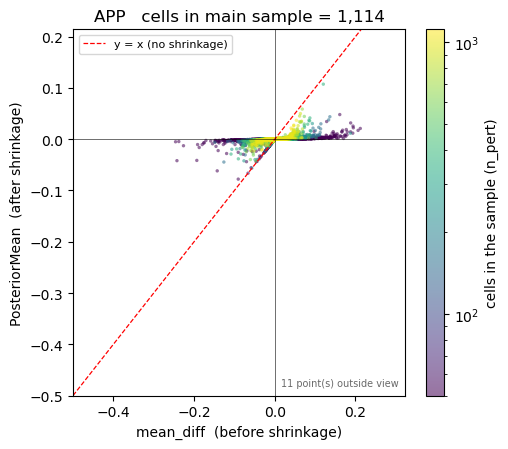

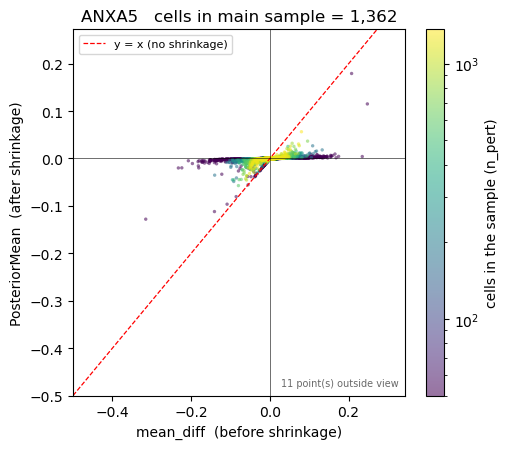

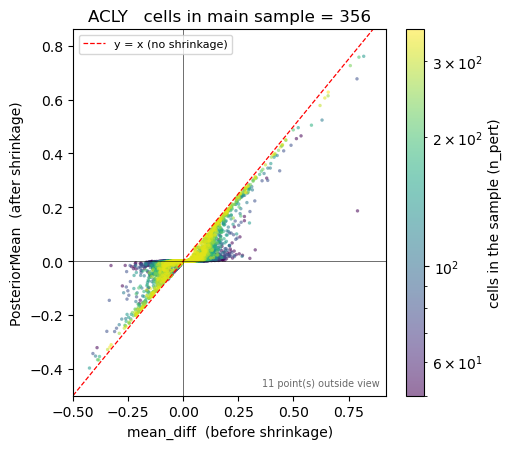

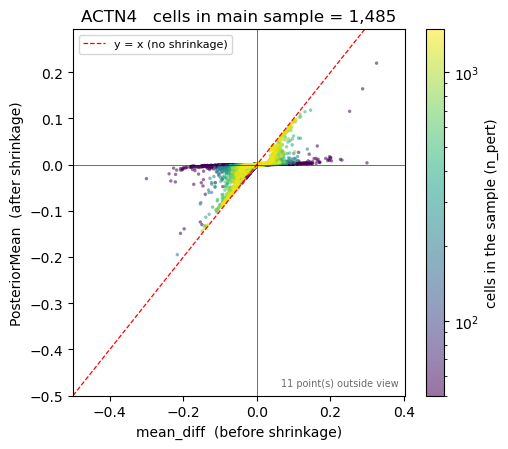

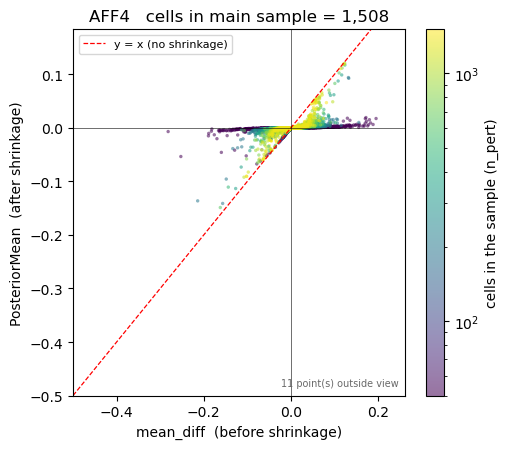

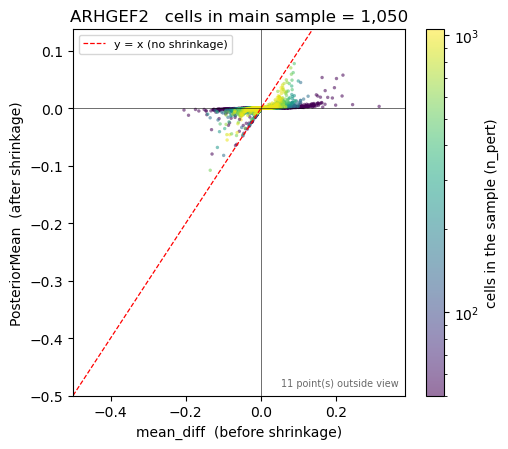

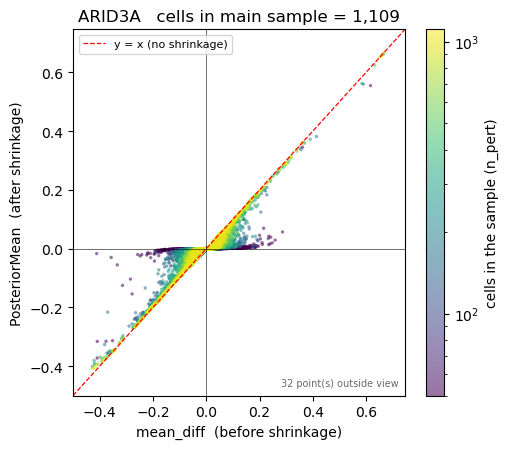

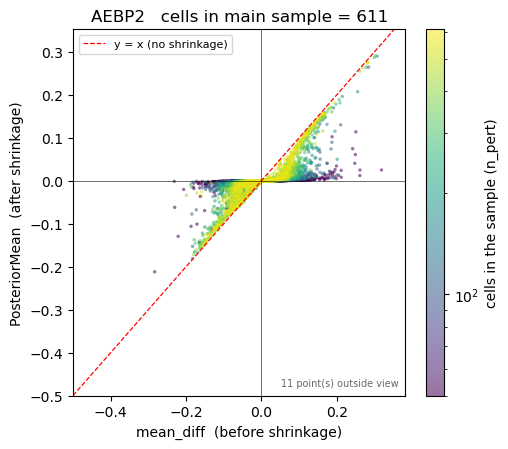

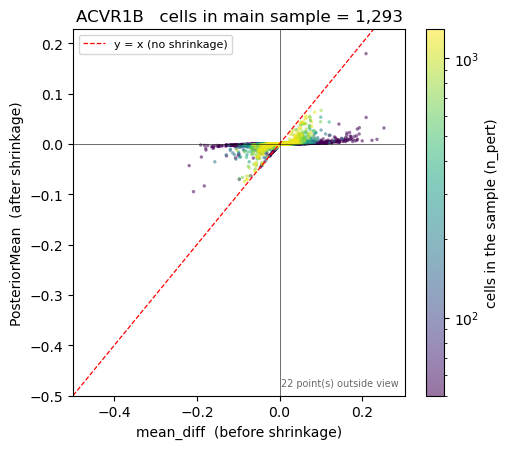

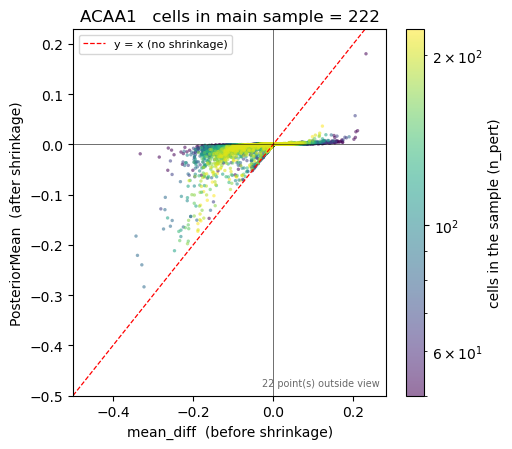

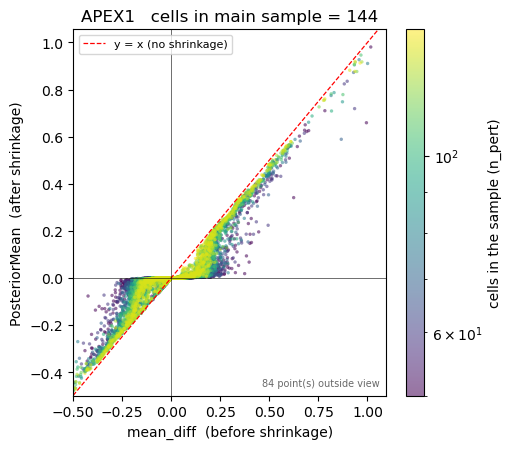

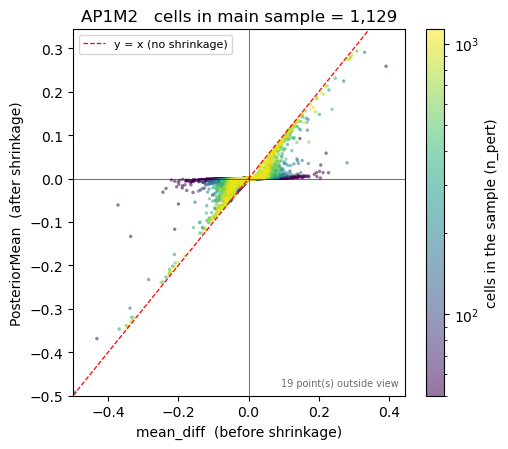

In [7]:
from matplotlib.colors import LogNorm

N_PERTS_TO_PLOT = 12      # perturbations with the strongest main effect first
AXIS_FLOOR = -0.5         # never show below this: on-target knockdowns reach -3.3
                          # and would squash every other point into a sliver

order = (df[df.is_main].groupby("base", observed=True).mean_diff
           .apply(lambda s: s.abs().max()).sort_values(ascending=False))
perts = list(order.head(N_PERTS_TO_PLOT).index)

for pert in perts:
    d = df[df.base == pert]
    n_main = int(d[d.is_main].n_pert.iloc[0])

    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    sc = ax.scatter(d.mean_diff, d.PosteriorMean, c=d.n_pert,
                    norm=LogNorm(vmin=max(d.n_pert.min(), 1), vmax=d.n_pert.max()),
                    cmap="viridis", s=6, alpha=.55, linewidths=0, rasterized=True)

    # limits from this perturbation's own values, but floored so the on-target
    # cluster does not set the scale
    pad = 0.04
    xlo, xhi = d.mean_diff.min(), d.mean_diff.max()
    ylo, yhi = d.PosteriorMean.min(), d.PosteriorMean.max()
    xr, yr = (xhi - xlo) or 1e-6, (yhi - ylo) or 1e-6
    xlo, xhi = max(xlo - pad * xr, AXIS_FLOOR), xhi + pad * xr
    ylo, yhi = max(ylo - pad * yr, AXIS_FLOOR), yhi + pad * yr

    # y = x over the overlapping range only
    lo, hi = max(xlo, ylo), min(xhi, yhi)
    if hi > lo:
        ax.plot([lo, hi], [lo, hi], "r--", lw=.9, label="y = x (no shrinkage)")
        ax.legend(fontsize=8, loc="upper left")

    ax.axhline(0, c="k", lw=.4); ax.axvline(0, c="k", lw=.4)
    ax.set(xlim=(xlo, xhi), ylim=(ylo, yhi),
           xlabel="mean_diff  (before shrinkage)",
           ylabel="PosteriorMean  (after shrinkage)",
           title=f"{pert}   cells in main sample = {n_main:,}")

    # say how much is out of view rather than hiding it silently
    hidden = int(((d.mean_diff < xlo) | (d.PosteriorMean < ylo) |
                  (d.mean_diff > xhi) | (d.PosteriorMean > yhi)).sum())
    if hidden:
        ax.text(.98, .02, f"{hidden:,} point(s) outside view", transform=ax.transAxes,
                ha="right", va="bottom", fontsize=7, color="dimgray")

    fig.colorbar(sc, ax=ax, label="cells in the sample (n_pert)")
    plt.tight_layout()
    plt.show()

## 3. Example ladders

One (perturbation, gene) pair at a time: the 11 estimates ordered by cell count, before
and after. Pick a strong effect and a null one — they behave very differently.

In [ ]:
def show_ladder(pert, gene, data=df):
    rows = data[(data.base == pert) & (data.gene == gene)].sort_values("n_pert")
    if rows.empty:
        print(f"no rows for {pert}/{gene}"); return
    print(f"  {pert} / {gene}")
    print(f"    {'n_pert':>7} {'before':>10} {'after':>10} {'se':>9} {'kept':>7} {'lfsr':>7}")
    for r in rows.itertuples():
        kept = r.PosteriorMean / r.mean_diff if abs(r.mean_diff) > 1e-12 else np.nan
        print(f"    {r.n_pert:>7} {r.mean_diff:>+10.5f} {r.PosteriorMean:>+10.5f} "
              f"{r.se:>9.5f} {kept:>7.2%} {r.lfsr:>7.3f}"
              f"{'  <- main' if r.is_main else ''}")
    print()

strength = df[df.is_main].set_index(["base","gene"]).mean_diff.abs().sort_values(ascending=False)
print("=== strongest effect ===");        show_ladder(*strength.index[0])
print("=== moderate (99.9th pct) ===");   show_ladder(*strength.index[len(strength)//1000])
print("=== null (median) ===");           show_ladder(*strength.index[len(strength)//2])

## 4. Does shrinkage reduce the spread across the ladder?

Per (perturbation, gene), the standard deviation of the 11 estimates — before vs after.

In [ ]:
spread = (df.groupby(["base", "gene"], observed=True)
            .agg(sd_before=("mean_diff", "std"),
                 sd_after=("PosteriorMean", "std"),
                 main_before=("mean_diff", lambda s: s.iloc[0]),
                 effect=("mean_diff", lambda s: s.abs().max()))
            .dropna())
print(spread[["sd_before","sd_after"]].describe(percentiles=[.5,.9,.99]).round(5).to_string())
print(f"\nmedian sd shrank from {spread.sd_before.median():.5f} to {spread.sd_after.median():.5f} "
      f"({spread.sd_after.median()/spread.sd_before.median():.1%} of the original)")

# but is the RELATIVE spread better or worse? CV against the main estimate
strong = spread[spread.effect > spread.effect.quantile(.99)]
print(f"\ntop 1% of effects (n={len(strong):,}):")
print(f"  sd_before/|effect|  median {(strong.sd_before/strong.effect).median():.3f}")
print(f"  sd_after /|effect|  median {(strong.sd_after /strong.effect).median():.3f}")

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
s = spread.sample(min(200_000, len(spread)), random_state=0)
ax[0].hexbin(s.sd_before, s.sd_after, gridsize=60, bins="log", mincnt=1)
lim = np.nanpercentile(s.sd_before, 99.5)
ax[0].plot([0, lim], [0, lim], "r--", lw=1, label="no change")
ax[0].set(xlim=(0, lim), ylim=(0, lim), xlabel="sd across 11 samples, before",
          ylabel="after", title="spread per (perturbation, gene)")
ax[0].legend()

for lab, col in (("before", "sd_before"), ("after", "sd_after")):
    ax[1].hist(np.log10(s[col].replace(0, np.nan).dropna()), bins=80, alpha=.55, label=lab)
ax[1].set(xlabel="log10 sd across the 11 samples", ylabel="count",
          title="distribution of spread")
ax[1].legend()
plt.tight_layout()

## 5. Deviation from the main estimate vs precision

Before shrinkage the deviation should fall as `√(1 − n/N)` (subsamples are drawn without
replacement from the same cells, so they converge on the main estimate as `n → N`).
After shrinkage there is no reason for that to hold.

In [ ]:
bins = [0, .15, .3, .45, .6, .75, .9, 1.0]
sub["bin"] = pd.cut(sub.frac_cells, bins)
g = (sub.groupby("bin", observed=True)
        .agg(n=("dev_before","size"), mean_n=("n_pert","mean"),
             mean_se=("se","mean"),
             bias_before=("dev_before","mean"), sd_before=("dev_before","std"),
             bias_after=("dev_after","mean"),  sd_after=("dev_after","std"),
             kept=("shrink","median")))
g["sd_ratio"] = g.sd_after / g.sd_before
print(g.round(6).to_string())

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
x = np.array([iv.mid for iv in g.index], dtype=float)
ax[0].plot(x, g.sd_before, "o-", label="before")
ax[0].plot(x, g.sd_after, "s-", label="after")
ax[0].set(xlabel="n_sub / n_main", ylabel="sd of deviation from main",
          title="spread vs precision", yscale="log"); ax[0].legend()

ax[1].plot(x, g.sd_ratio, "o-", color="C3")
ax[1].axhline(1, ls="--", c="k", lw=1)
ax[1].set(xlabel="n_sub / n_main", ylabel="sd after / sd before",
          title="does shrinkage compress the ladder evenly?")

ax[2].plot(x, g.kept, "o-", color="C2")
ax[2].set(xlabel="n_sub / n_main", ylabel="median PosteriorMean / mean_diff",
          title="fraction of the estimate retained")
plt.tight_layout()

## 6. Shrinkage as a function of cell count

The headline check: `ashr` conditions on `se`, so low-`n` rows should be shrunk harder.
If the retained fraction is *flat* in `n`, the shared prior is dominating and the extra
cells are buying less than they should.

In [ ]:
q = df.copy()
q["kept"] = q.PosteriorMean / q.mean_diff.where(q.mean_diff.abs() > 1e-12)
q["nbin"] = pd.cut(q.n_pert, [0, 60, 150, 400, 1000, 3000, 10**6])
t = (q.groupby("nbin", observed=True)
      .agg(n=("kept","size"), mean_se=("se","mean"),
           raw=("mean_diff", lambda s: s.abs().mean()),
           post=("PosteriorMean", lambda s: s.abs().mean()),
           median_kept=("kept","median"),
           sig=("lfsr", lambda s: (s < .05).mean())))
t["kept_of_magnitude"] = t.post / t.raw
print(t.round(5).to_string())
print("\nIf `sig` (lfsr<0.05) rises as cell count FALLS, the shared prior is letting")
print("noisy low-n rows borrow confidence from the pool — see section 7.")